## Implementing simple Chatbot using Langgraph

In [7]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
# Merges two lists of messages, updating existing messages by ID.
from langgraph.graph.message import add_messages

In [8]:
from typing import List


class State(TypedDict):
    messages: Annotated[List[str], add_messages]

In [9]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA


##### Create OpenAI LLM model

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o')
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x11aadf110>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11aadf4d0>, root_client=<openai.OpenAI object at 0x11aadee90>, root_async_client=<openai.AsyncOpenAI object at 0x11aadf250>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********'))

##### Create GROQ LLM model

In [11]:
from langchain_groq import ChatGroq
groq_chat = ChatGroq(model='Gemma2-9b-It')
groq_chat

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11aadf9d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11aadfed0>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Create Graph

In [12]:
def superbot(state: State):
    output = groq_chat.invoke(input=state['messages'])
    print(f'LLM returned value: {output}')
    return {'messages': [output]}

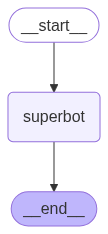

In [13]:
from IPython.display import display, Image

graph = StateGraph(State)

# Nodes
graph.add_node('superbot', superbot)

# Edges
graph.add_edge(start_key=START, end_key='superbot')
graph.add_edge(start_key='superbot', end_key=END)

# Compile the graph
graph_builder = graph.compile()

# Visualize
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#### Graph Invoke

In [14]:
graph_builder.invoke(input={
    'messages': ['Hi, my name is Dimo and I like lifting weights.']
})

LLM returned value: content="Hi Dimo, it's nice to meet you!  \n\nThat's awesome that you like lifting weights. It's a great way to stay fit and strong.  \n\nDo you have a favorite exercise?  Or are you training for anything specific?\n" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 22, 'total_tokens': 79, 'completion_time': 0.103636364, 'prompt_time': 0.001323138, 'queue_time': 0.186706276, 'total_time': 0.104959502}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='run--58e135f2-bbcd-4a05-a35c-3385f078fa36-0' usage_metadata={'input_tokens': 22, 'output_tokens': 57, 'total_tokens': 79}


{'messages': [HumanMessage(content='Hi, my name is Dimo and I like lifting weights.', additional_kwargs={}, response_metadata={}, id='b8d29cc7-d983-4a9c-961d-0c990eb37112'),
  AIMessage(content="Hi Dimo, it's nice to meet you!  \n\nThat's awesome that you like lifting weights. It's a great way to stay fit and strong.  \n\nDo you have a favorite exercise?  Or are you training for anything specific?\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 22, 'total_tokens': 79, 'completion_time': 0.103636364, 'prompt_time': 0.001323138, 'queue_time': 0.186706276, 'total_time': 0.104959502}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--58e135f2-bbcd-4a05-a35c-3385f078fa36-0', usage_metadata={'input_tokens': 22, 'output_tokens': 57, 'total_tokens': 79})]}

## Streaming the responses

In [17]:
response_stream = graph_builder.stream(input={
    'messages': "Do you remember what I have told you earlier"
}, stream_mode='values')

for event in response_stream:
    print(event)

{'messages': [HumanMessage(content='Do you remember what I have told you earlier', additional_kwargs={}, response_metadata={}, id='a7c6610c-bda0-42c6-a3cd-3bc629ab3bcc')]}
LLM returned value: content="As a large language model, I have no memory of past conversations. Every interaction we have is a fresh start.\n\nIf you'd like to discuss something specific, please let me know and I'll be happy to help!\n" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 18, 'total_tokens': 68, 'completion_time': 0.090909091, 'prompt_time': 0.001248579, 'queue_time': 0.187917715, 'total_time': 0.09215767}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='run--a6b5e126-38c0-4fce-a407-7c4fd8ca0a54-0' usage_metadata={'input_tokens': 18, 'output_tokens': 50, 'total_tokens': 68}
{'messages': [HumanMessage(content='Do you remember what I have told you earlier', addit